In [1]:
import numpy as np
import matplotlib.pyplot as plt
import uproot
import awkward as ak

In [ ]:
# file_path = "/sps/t2k/eleblevec/Datasets/custom_dataset/e-/200-1000MeV/WCTE_center_iso/test_1_a5/merged_e-_200-1000MeV.root"
# file_path = "/sps/t2k/mferey/Data/WCTE_v1/WCTE_center_iso/WCSim_v1.12.20_nuPRISMBeamTest_16cShort_mPMT/e-/200-1000MeV/1/root_output_2000events.root"
file_path = "/sps/t2k/eleblevec/Datasets/custom_dataset/e-/200-1000MeV/WCTE_center_iso_erwan_cuts/1/ntuple_cut_ed_2000.root"
tree_name = "pure_root_tree"

root_file = uproot.open(file_path)
tree = root_file[tree_name]

In [3]:
tree.show()

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
eventType            | int32_t                  | AsDtype('>i4')
energy               | float                    | AsDtype('>f4')
vertex               | float[3]                 | AsDtype("('>f4', (3,))")
particleDir          | float[3]                 | AsDtype("('>f4', (3,))")
particleStop         | float[3]                 | AsDtype("('>f4', (3,))")
n_hits               | int32_t                  | AsDtype('>i4')
time_trigger         | float                    | AsDtype('>f4')
tubeIds              | int32_t[]                | AsJagged(AsDtype('>i4'))
hitx                 | float[]                  | AsJagged(AsDtype('>f4'))
hity                 | float[]                  | AsJagged(AsDtype('>f4'))
hitz                 | float[]                  | AsJagged(AsDtype('>f4'))
charge               | float[]                  | AsJ

In [4]:
tubes_ids = ak.flatten(tree["tubeIds"].arrays(library="ak")["tubeIds"])

print(tubes_ids[:10])
print(f"Nb tubes : {len(np.unique(tubes_ids))}")
print(f"Max tube ID : {np.max(tubes_ids)}")
print(f"Min tube ID : {np.min(tubes_ids)}")

[1598, 1615, 1605, 1606, 1612, 1611, 402, 1608, 401, 1697]
Nb tubes : 1995
Max tube ID : 1995
Min tube ID : 1


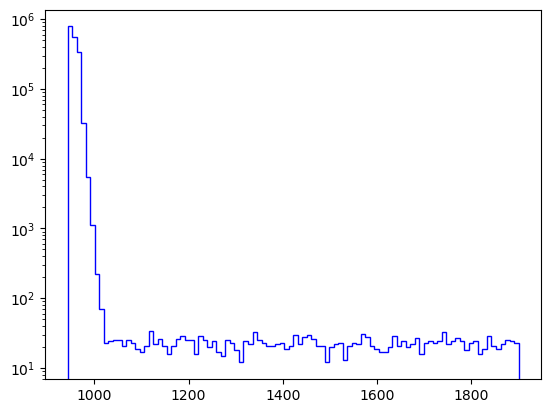

In [25]:
time = ak.flatten(tree["time"].arrays(library="ak")["time"])

fig, ax = plt.subplots()
plt.hist(time, bins=100, histtype='step', color='blue')
plt.yscale('log')
plt.show()

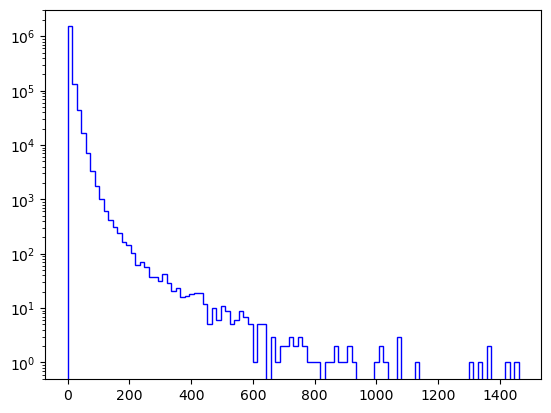

In [6]:
charge = ak.flatten(tree["charge"].arrays(library="ak")["charge"])

fig, ax = plt.subplots()
plt.hist(charge, bins=100, histtype='step', color='blue')
plt.yscale('log')
plt.show()

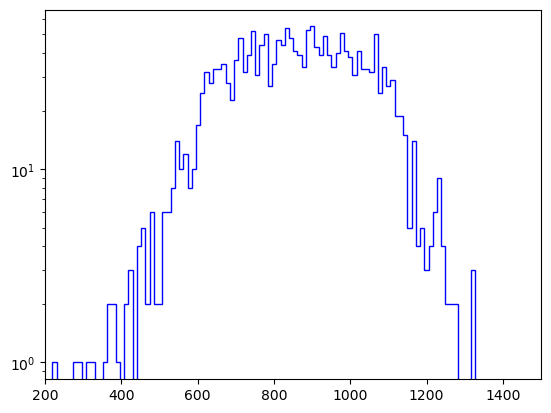

In [11]:
n_digi_hits = tree["n_hits"].array()

fig, ax = plt.subplots()
plt.hist(n_digi_hits, bins=100, histtype='step', color='blue')

plt.yscale('log')
plt.xlim(200, 1500)
plt.show()


In [ ]:
event_id = 1605
pmt_time_event =  tree["pmt_time"].array()[event_id]
pmt_charge_event = tree["pmt_charge"].array()[event_id]

fig, ax = plt.subplots(2, 1)
ax[0].hist(pmt_time_event, bins=100, histtype='step', color='blue')
ax[0].yscale('log')
ax[1].hist(pmt_charge_event, bins=100, histtype='step', color='blue')
ax[1].yscale('log')
plt.show()

: 